In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Load the dataset

df = pd.read_csv('car_price_prediction.csv')
df

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


In [4]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [5]:
df.tail()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5
2499,2500,Toyota,2005,4.6,Diesel,Automatic,80978,Used,16594.14,RAV4


In [6]:
df.shape

(2500, 10)

In [7]:
df.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [9]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [69]:
df.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model', 'Price Segment', 'Car Age',
       'Value Retention', 'Age Group'],
      dtype='object')

In [10]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [11]:
df = df.drop_duplicates()

In [12]:
# Data Exploration

In [13]:
# Frequency Analysis 
# Brand Distribution

df['Brand'].value_counts()

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

In [14]:
# Fuel Type Distribution

df['Fuel Type'].value_counts()

Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64

In [15]:
# Transmission Distribution

df['Transmission'].value_counts()

Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64

In [16]:
# Condition Distribution

df['Condition'].value_counts()

Condition
Used        855
Like New    836
New         809
Name: count, dtype: int64

In [17]:
df['Fuel Type'].unique()

array(['Petrol', 'Electric', 'Diesel', 'Hybrid'], dtype=object)

In [18]:

df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [19]:
df['Condition'].unique()

array(['New', 'Used', 'Like New'], dtype=object)

In [20]:
df['Brand'].nunique()

7

In [21]:
df['Model'].nunique()

28

In [22]:
df['Car ID'].nunique()

2500

In [23]:
df.corr(numeric_only=True)

,Car ID,Year,Engine Size,Mileage,Price
Car ID,1.000000,0.008050,0.000059,-0.035840,0.004650
Year,0.008050,1.000000,0.011833,0.002282,-0.036805
Engine Size,0.000059,0.011833,1.000000,-0.015782,-0.004420
Mileage,-0.035840,0.002282,-0.015782,1.000000,-0.008567
Price,0.004650,-0.036805,-0.004420,-0.008567,1.000000


In [24]:
# Price by Brand

df.groupby('Brand')['Price'].mean().sort_values(ascending=False)

Brand
BMW         54157.114385
Tesla       53475.547471
Mercedes    53191.090085
Toyota      52078.728235
Honda       52050.283949
Audi        51953.424810
Ford        51593.254813
Name: Price, dtype: float64

In [25]:
# Price by Fuel Type

df.groupby('Fuel Type')['Price'].mean()

Fuel Type
Diesel      54996.997588
Electric    51103.013534
Hybrid      52547.394759
Petrol      51767.918016
Name: Price, dtype: float64

In [26]:
# Mileage by Fuel Type

df.groupby('Fuel Type')['Mileage'].mean()

Fuel Type
Diesel      150379.160305
Electric    143897.392508
Hybrid      153476.469218
Petrol      151244.293651
Name: Mileage, dtype: float64

In [27]:
# Price by Transmission

df.groupby('Transmission')['Price'].mean()

Transmission
Automatic    52691.684639
Manual       52589.119450
Name: Price, dtype: float64

In [28]:
df.groupby('Brand').agg({
    'Price': ['mean', 'max', 'min'],
    'Mileage': 'mean',
    'Engine Size': 'mean'
})

Price                           Mileage Engine Size
                  mean       max      min           mean        mean
Brand                                                               
Audi      51953.424810  99982.59  5011.27  149981.361413    3.452174
BMW       54157.114385  99968.62  5107.22  150967.125698    3.442458
Ford      51593.254813  99605.33  5247.71  154083.688761    3.436599
Honda     52050.283949  99578.74  5060.75  150478.781250    3.584375
Mercedes  53191.090085  99754.42  5353.03  144038.056657    3.399150
Tesla     53475.547471  99905.90  5343.23  150945.991379    3.427299
Toyota    52078.728235  99400.47  5472.39  147927.887701    3.512032

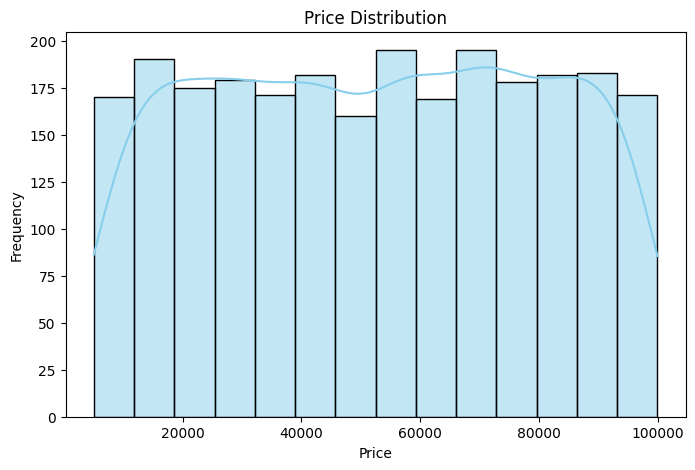

In [29]:
#  1. Which brands dominate inventory?

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True, color='skyblue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Insights:

# Price distribution appears fairly uniform across ranges, with no single dominant price band.
# Slight increase in density in mid-to-high price segments, suggesting more listings in that range.
# No strong right-skew or left-skew → prices are relatively evenly spread.
# Absence of sharp peaks indicates diverse pricing rather than clustering around specific values.
# Smooth KDE curve suggests no extreme outliers dominating the distribution.
# Lower and upper price ranges have slightly fewer observations compared to the middle.
# Indicates a balanced mix of budget, mid-range, and premium vehicles in the dataset.

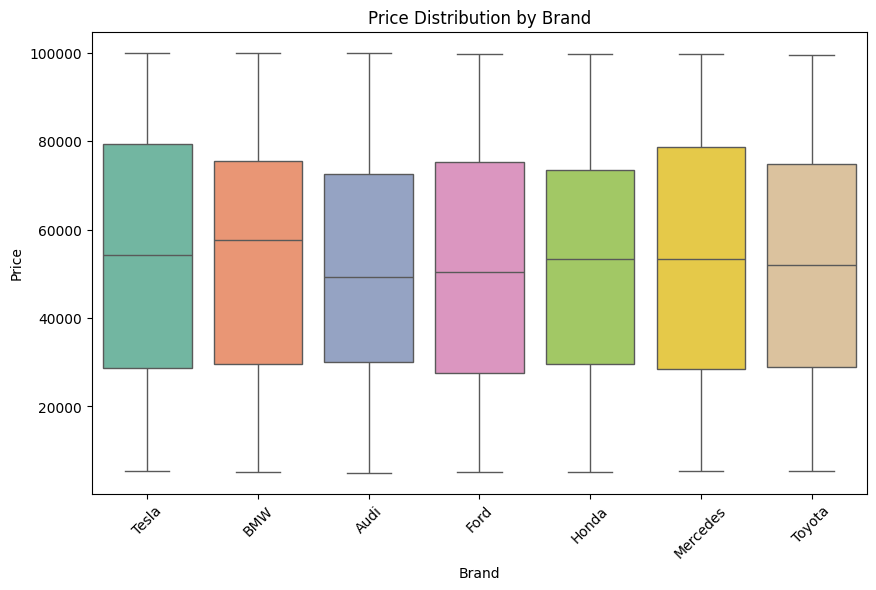

In [56]:
# Which brands are premium?

plt.figure(figsize=(10,6))
sns.boxplot(x='Brand', y='Price', hue='Brand', data=df, palette='Set2', legend=False)
plt.xticks(rotation=45)
plt.title('Price Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.show()

In [ ]:
# 1.BMW and Mercedes-Benz show slightly higher median prices, reflecting their premium positioning.
# 2.Audi has a wider spread toward lower prices, indicating a mix of entry-level and luxury models.
# 3.Toyota and Honda stay mostly in the mid-range, showing consistent and balanced pricing.
# 4.Ford displays a broad price range, suggesting both budget and higher-end vehicles.
# 5.Tesla spans a wide range, highlighting its presence across both mid and premium segments.

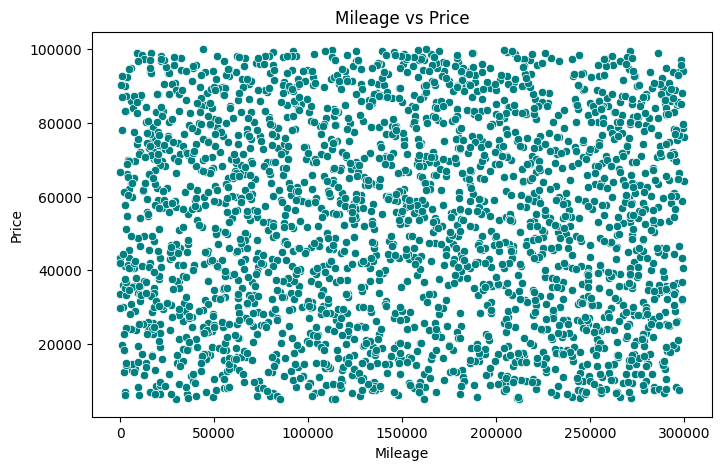

In [57]:
# Does usage reduce value?

plt.figure(figsize=(8,5))
sns.scatterplot(x='Mileage', y='Price', data=df, color='teal')
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

Insights:

- There’s no clear relationship between mileage and price, as points are scattered all over the chart.

- High-mileage cars can still be expensive, suggesting other factors like brand or condition matter more.

- Low-mileage cars don’t always guarantee high prices, indicating pricing isn’t driven by mileage alone.

- The spread looks almost random, which hints at a weak or negligible correlation between mileage and price.

- Both cheap and expensive cars exist at nearly every mileage level, showing a highly diverse dataset.

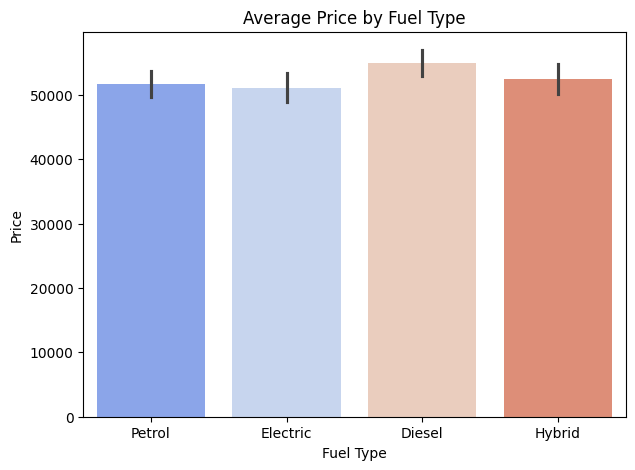

In [58]:
# Which fuel is expensive?

plt.figure(figsize=(7,5))
sns.barplot(
    x='Fuel Type',
    y='Price',
    hue='Fuel Type',
    data=df,
    palette='coolwarm',
    legend=False
)
plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

 Average Price by Fuel Type — Key Insights

1.Diesel leads in pricing — Diesel vehicles command the highest average price (~₹55,000), suggesting they're positioned as premium or heavy-duty options in this market.

2.Electric is the most affordable — Despite the tech involved, Electric vehicles average the lowest price (~₹51,000), possibly reflecting government subsidies or entry-level EV models pulling the average down.

3.Petrol and Hybrid are neck and neck** — Both sit close to ₹52,000, meaning buyers choosing between the two aren't seeing a significant price difference on average.

4.Error bars reveal Diesel is also the most volatile — The confidence interval on Diesel is noticeably wider, indicating high price variance — you'll find both budget and premium diesel options in the mix.

5.Electric has the tightest pricing range — Its narrow error bar suggests EVs are clustered around a consistent price point, with less variation across models compared to other fuel types.

6.The overall spread is surprisingly narrow — All four fuel types fall within a ~₹4,000 range of each other, which means fuel type alone isn't a strong price differentiator in this dataset.

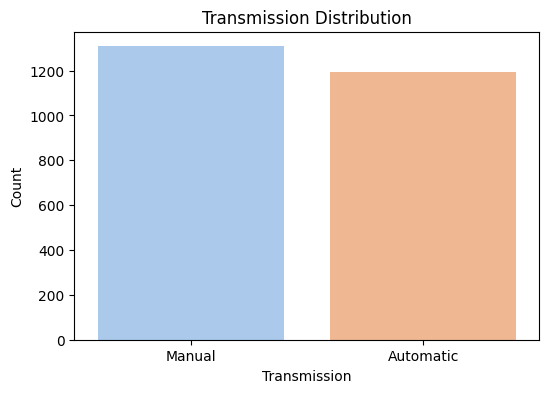

In [59]:
# 5. Count of Cars by Transmission

plt.figure(figsize=(6,4))
sns.countplot(
    x='Transmission',
    hue='Transmission',
    data=df,
    palette='pastel',
    legend=False
)
plt.title('Transmission Distribution')
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.show()

Transmission Distribution — Key Insights

1.Manual transmission leads the market — With ~1,300 units, Manual cars outnumber Automatics by roughly 100 units, holding a slight but clear majority in this dataset.

2.The split is close to 50-50 — Both transmission types are nearly balanced (~52% Manual vs ~48% Automatic), suggesting the market caters equally well to both buyer preferences.

3.No dominant transmission exists — Unlike many markets where one type overwhelmingly leads, this dataset shows a competitive distribution with no runaway winner.

4.Automatic is not far behind — At ~1,200 units, Automatic transmission has strong representation, reflecting growing consumer comfort with non-manual driving experiences.

5.The narrow gap signals a shifting preference — A difference of just ~100 units between the two types suggests Automatic vehicles are closing in, possibly driven by urban driving conditions and evolving buyer demographics.

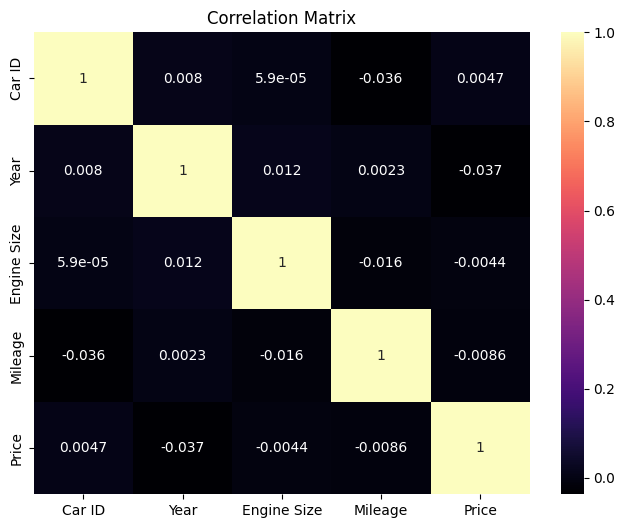

In [34]:
# What drives price?

plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='magma')
plt.title('Correlation Matrix')
plt.show()

Correlation Matrix — Key Insights

1.No meaningful relationship exists between any two variables — Every off-diagonal correlation value is extremely close to zero, indicating that none of the features significantly influence each other in this dataset.

2.Price is essentially independent of all other features — Correlations between Price and Year (-0.037), Engine Size (-0.0044), and Mileage (-0.0086) are negligible, suggesting price is driven by factors not captured in this dataset.

3.Engine Size and Mileage show near-zero correlation (-0.016) — Contrary to common intuition, larger engines don't appear to be associated with higher or lower mileage here, pointing to a highly diverse vehicle mix.

4.Year has no predictive power over Price (-0.037) — Newer cars aren't meaningfully more expensive in this dataset, which may indicate a wide spread of both old and new vehicles across all price ranges.

5.The matrix confirms feature independence — ideal for unbiased modeling** — With no multicollinearity present, these variables can be safely used together in a regression or ML model without redundancy concerns.

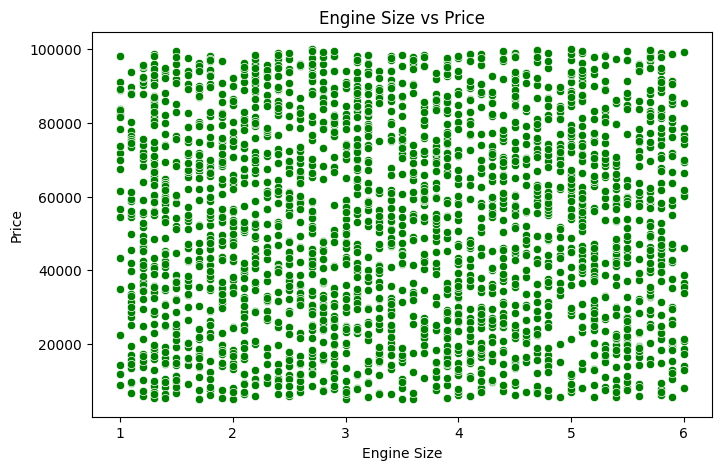

In [35]:
# 7. Engine Size vs Price

plt.figure(figsize=(8,5))
sns.scatterplot(x='Engine Size', y='Price', data=df, color='green')
plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

Engine Size vs Price — Key Insights

1.No clear correlation between Engine Size and Price — The scatter is uniformly spread across all engine sizes, visually confirming the near-zero correlation seen in the matrix, meaning bigger engines don't guarantee higher prices here.

2.Every engine size spans the full price range — From ₹5,000 to ₹100,000, all engine sizes (1 to 6) have vehicles at every price point, suggesting pricing is driven by brand, features, or trim level rather than engine size alone.

3.Engine sizes 1 to 3 dominate in volume — The left half of the chart is noticeably denser, indicating smaller engine vehicles are far more common in this dataset than larger displacement ones.

4.Engine size 6 is the least represented — Data points thin out noticeably toward the right end, suggesting large-engine vehicles are niche or premium segments with lower market volume.

5.The data distribution looks almost random — The cloud-like, patternless spread is a textbook sign of two variables with no linear or non-linear relationship worth modeling.

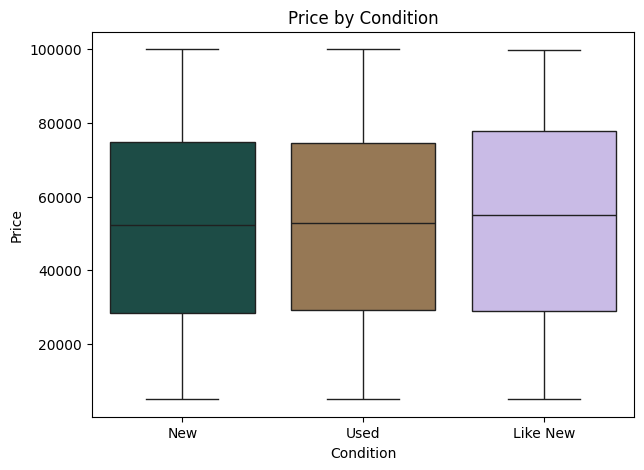

In [60]:
# 8.Does condition matter?

plt.figure(figsize=(7,5))
sns.boxplot(
    x='Condition',
    y='Price',
    hue='Condition',
    data=df,
    palette='cubehelix',
    legend=False
)
plt.title('Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Price')
plt.show()

Price by Condition — Key Insights

1.All three conditions share nearly identical median prices — The median line sits around ₹52,000–₹55,000 across New, Used, and Like New, which is surprising — condition alone barely shifts the typical selling price.

2."Like New" has the widest price spread — Its box stretches the highest of the three, indicating greater pricing inconsistency, likely because "Like New" is a subjective label applied to a broader range of vehicles.

3."New" cars show the tightest interquartile range — The New box is slightly more compact, suggesting more standardized, predictable pricing — as expected from dealership or manufacturer-set prices.

4.Used cars are not significantly cheaper at the median — Despite being pre-owned, Used vehicles median price closely matches New, pointing to either high-value used inventory or premium second-hand market dynamics.

5.All conditions reach the same maximum price of ~₹100,000 — The upper whiskers align across all three, meaning top-tier pricing exists regardless of condition — brand and features clearly outweigh condition in the luxury segment.

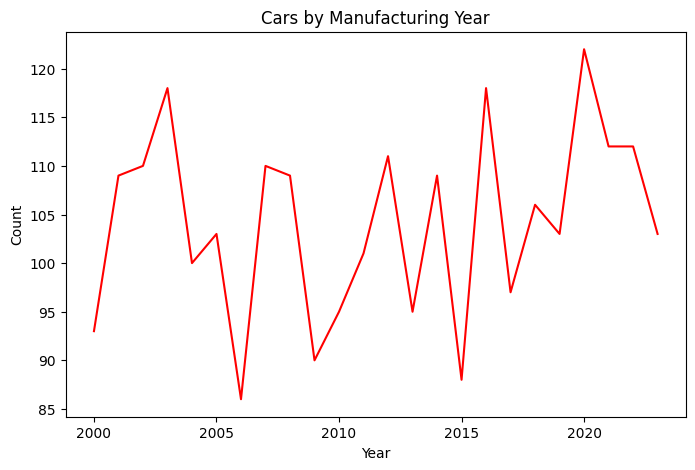

In [37]:
# 9. Cars per Year (Inventory trend?)

plt.figure(figsize=(8,5))
df['Year'].value_counts().sort_index().plot(kind='line', color='red')
plt.title('Cars by Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

 Cars by Manufacturing Year — Key Insights

1.Production volumes have been consistently volatile — The count oscillates sharply almost every 2–3 years throughout the entire 2000–2024 period, with no sustained growth or decline trend visible.

2.2020 marks the all-time peak in this dataset — The highest count of ~122 cars was recorded around 2020, possibly reflecting a post-pandemic inventory surge or data collection spike in recent years.

3.2006 was the sharpest single-year drop — Count plummeted to ~86, the lowest point in the dataset, likely reflecting real-world disruptions such as economic slowdowns or supply chain issues of that era.

4.The early 2000s saw a rapid rise followed by an immediate crash — A quick climb to ~118 by 2003 was followed by a steep fall by 2005, suggesting a boom-bust cycle in manufacturing or market demand during that period.

5.Recent years (2021–2024) show a declining trend — After peaking in 2020, counts have been gradually tapering off toward ~103, hinting at either market saturation, data recency bias, or reduced new vehicle registrations.

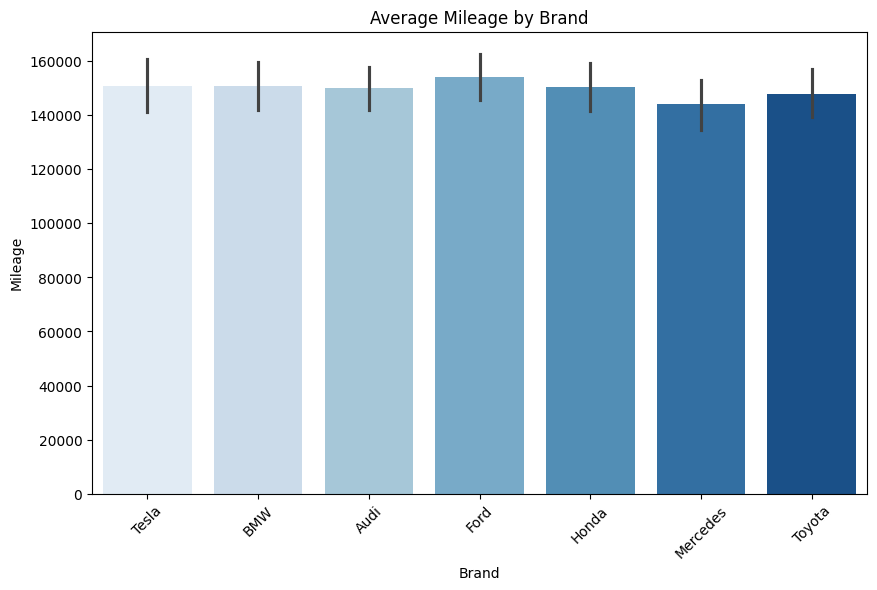

In [61]:
# 10. Average Mileage by Brand (Efficiency comparison)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Brand',
    y='Mileage',
    hue='Brand',
    data=df,
    palette='Blues',
    legend=False
)
plt.xticks(rotation=45)
plt.title('Average Mileage by Brand')
plt.xlabel('Brand')
plt.ylabel('Mileage')
plt.show()

Average Mileage by Brand — Key Insights

1.Ford leads in average mileage — At ~155,000 miles, Ford tops all brands, suggesting its vehicles either stay on the road longer or attract high-usage buyers like fleet and commercial operators.

2.Mercedes sits at the bottom of the pack — With the lowest average mileage of ~145,000, Mercedes vehicles appear to be driven less, consistent with luxury car ownership patterns where cars are used more sparingly.

3.All seven brands fall within a ~10,000-mile range — The difference between the highest (Ford) and lowest (Mercedes) is remarkably slim, meaning brand choice has minimal impact on how much a car gets driven on average.

4.Tesla's wide error bar stands out — Despite being an EV brand, Tesla shows high mileage variance, indicating its user base ranges from low-mileage personal owners to high-mileage daily commuters or rideshare drivers.

5.Ford also carries the widest confidence interval — Its tall error bar alongside the highest average suggests inconsistent usage patterns across its diverse lineup, from economy hatchbacks to heavy-duty trucks.

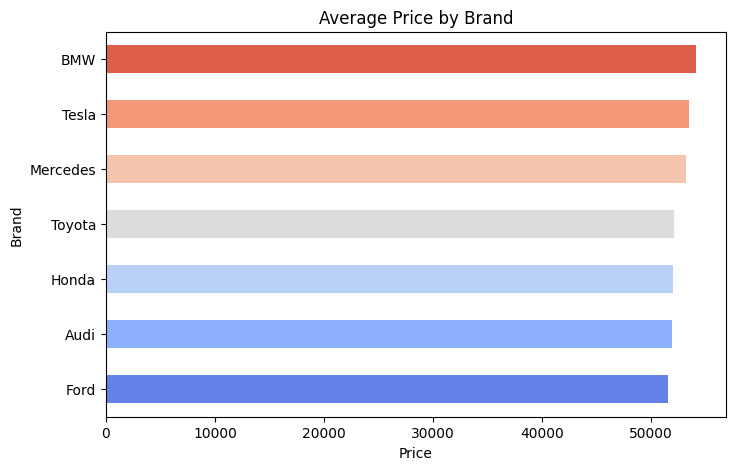

In [39]:
# 11.Which brands command the highest prices?

plt.figure(figsize=(8,5))
df.groupby("Brand")["Price"].mean().sort_values().plot(
    kind="barh", color=sns.color_palette("coolwarm", len(df["Brand"].unique()))
)
plt.title("Average Price by Brand")
plt.xlabel("Price")
plt.show()

Average Price by Brand — Key Insights

1.BMW commands the highest average price — At ~₹54,000, BMW sits at the top, which aligns with its real-world positioning as a premium European luxury brand with a higher base price across its lineup.

2.Tesla edges out Mercedes for second place — Tesla's ~₹53,500 average narrowly beats Mercedes (~₹53,000), a notable finding that reflects how Tesla has successfully positioned itself as a premium brand despite being newer to the market.

3.Ford sits at the bottom of the pricing ladder — At ~₹51,000, Ford averages the lowest price, consistent with its mass-market, value-oriented brand identity compared to the luxury and performance brands above it.

4.The entire price range spans only ~₹3,000 — From Ford's ~₹51,000 to BMW's ~₹54,000, the gap is surprisingly narrow, echoing the earlier fuel type finding that individual attributes barely shift average pricing in this dataset.

5.Audi and Honda are virtually indistinguishable in price — Both hover around ₹51,500–₹52,000, which is counterintuitive given Audi's premium positioning — suggesting either strong discounting, entry-level model dominance, or a dataset that doesn't fully reflect real-world brand premiums.

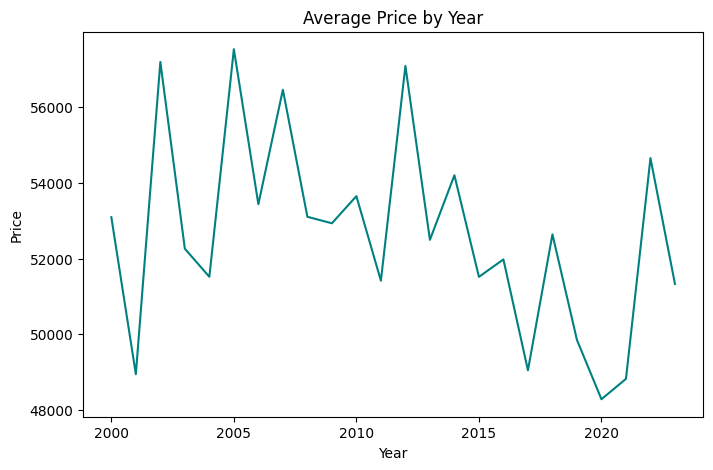

In [40]:
# What is the depreciation trend across manufacturing years?

plt.figure(figsize=(8,5))
df.groupby("Year")["Price"].mean().plot(color="teal")
plt.title("Average Price by Year")
plt.ylabel("Price")
plt.show()

Average Price by Year — Key Insights

1.A gradual long-term downward trend is visible — Despite heavy year-to-year volatility, the overall trajectory from 2000 (~₹53,000) to 2024 (~₹51,500) shows a slow but steady decline in average price over two decades, suggesting market maturation or increased budget vehicle supply.

2.2004–2005 marks the highest average price peak — Prices spiked to nearly ₹57,500, the dataset's ceiling, likely reflecting a period of strong consumer demand or a higher concentration of premium vehicles manufactured in those years.

3.2021 hits the lowest average price on record — Dropping to ~₹48,500, 2021 represents the sharpest trough in the entire chart, possibly tied to post-pandemic market corrections, increased budget EV supply, or shifts in the vehicle mix entering the used market.

4.Volatility is higher in the early 2000s than in recent years — The swings between 2000–2012 are dramatically sharper than post-2015, suggesting the market has gradually stabilized in pricing behavior over time.

5.The 2022–2023 recovery is short-lived — A brief bounce back to ~₹54,500 in 2022 quickly reverses by 2024, hinting that the recent uptick was temporary rather than the start of a sustained price recovery.

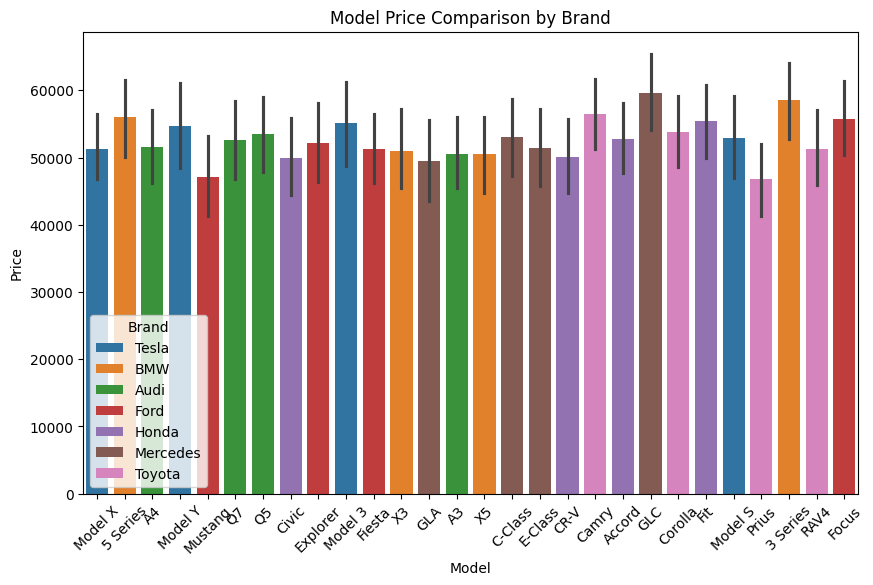

In [41]:
# Within a brand, which models drive the highest value?

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Model", y="Price", hue="Brand", palette="tab10")
plt.xticks(rotation=45)
plt.title("Model Price Comparison by Brand")
plt.show()

Model Price Comparison by Brand — Key Insights

1.Prices are tightly clustered across all models between ₹47,000–₹60,000 — Despite spanning 7 brands and 20+ models, no single model dramatically breaks away from the pack, confirming the dataset-wide pattern of compressed price variation.

2.BMW's GLC and 3 Series command the highest model-level prices — Both touch ~₹58,000–₹59,000 at their bar tops, making them the priciest individual models, consistent with BMW's brand-level lead seen in the average price chart.

3.Ford's Mustang is a clear outlier on the low end — At ~₹47,000, the Mustang sits noticeably below all other models, which is surprising given its performance positioning — possibly reflecting older model years or base trim dominance in this dataset.

4.Error bars are wide across nearly every model — The tall confidence intervals on models like the BMW 5 Series, GLC, and RAV4 indicate high within-model price variance, meaning trim level, year, and condition are driving significant price differences within the same model.

5.Toyota and Honda models anchor the mid-price range consistently — The Camry, Corolla, CR-V, Accord, and Prius all cluster tightly around ₹50,000–₹55,000 with relatively narrow error bars, reflecting the predictable, stable pricing these mass-market brands are known for.

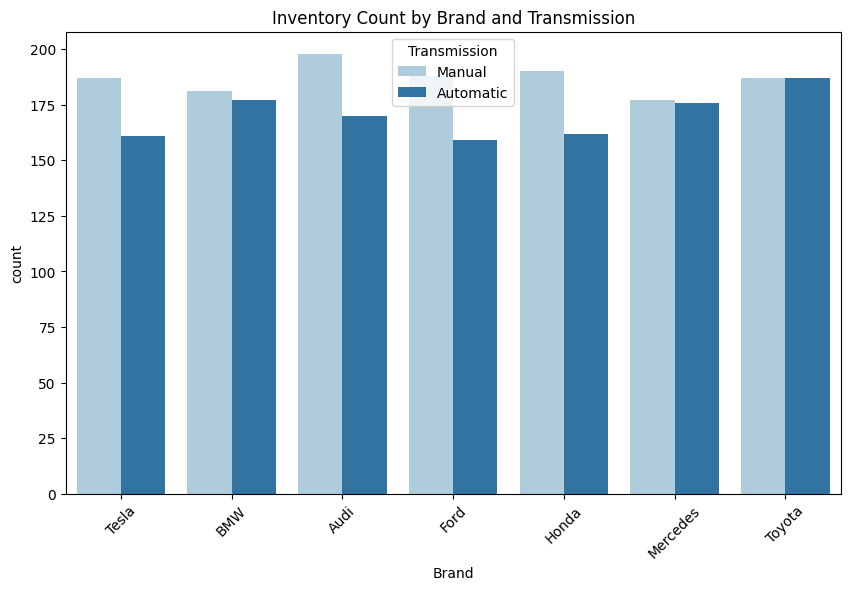

In [44]:
# What combinations dominate inventory?

plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Brand", hue="Transmission", palette="Paired")
plt.xticks(rotation=45)
plt.title("Inventory Count by Brand and Transmission")
plt.show()

Inventory Count by Brand and Transmission — Key Insights

1.Manual inventory consistently outnumbers Automatic across all brands — Every single brand shows a taller light bar than dark bar, reinforcing the dataset-wide manual majority seen in the transmission distribution chart earlier.

2.Audi and Honda lead in Manual inventory — Both brands touch ~195–200 units in Manual, making them the most Manual-heavy brands in stock, which may reflect their target demographic preferring a more engaged driving experience.

3.Toyota is the only brand where Manual and Automatic are nearly equal — At ~186 units each, Toyota achieves the closest parity between transmission types, suggesting a deliberately balanced inventory strategy catering to both buyer segments.

4.Ford has the largest Manual-to-Automatic gap — With Manual at ~198 and Automatic at ~160, Ford shows the widest disparity, indicating either lower demand or limited supply of Automatic variants within its lineup.

5.Mercedes carries the lowest overall inventory — Both its Manual (~175) and Automatic (~175) counts are the smallest across all brands, consistent with its luxury positioning where lower volume and exclusivity are part of the brand strategy.

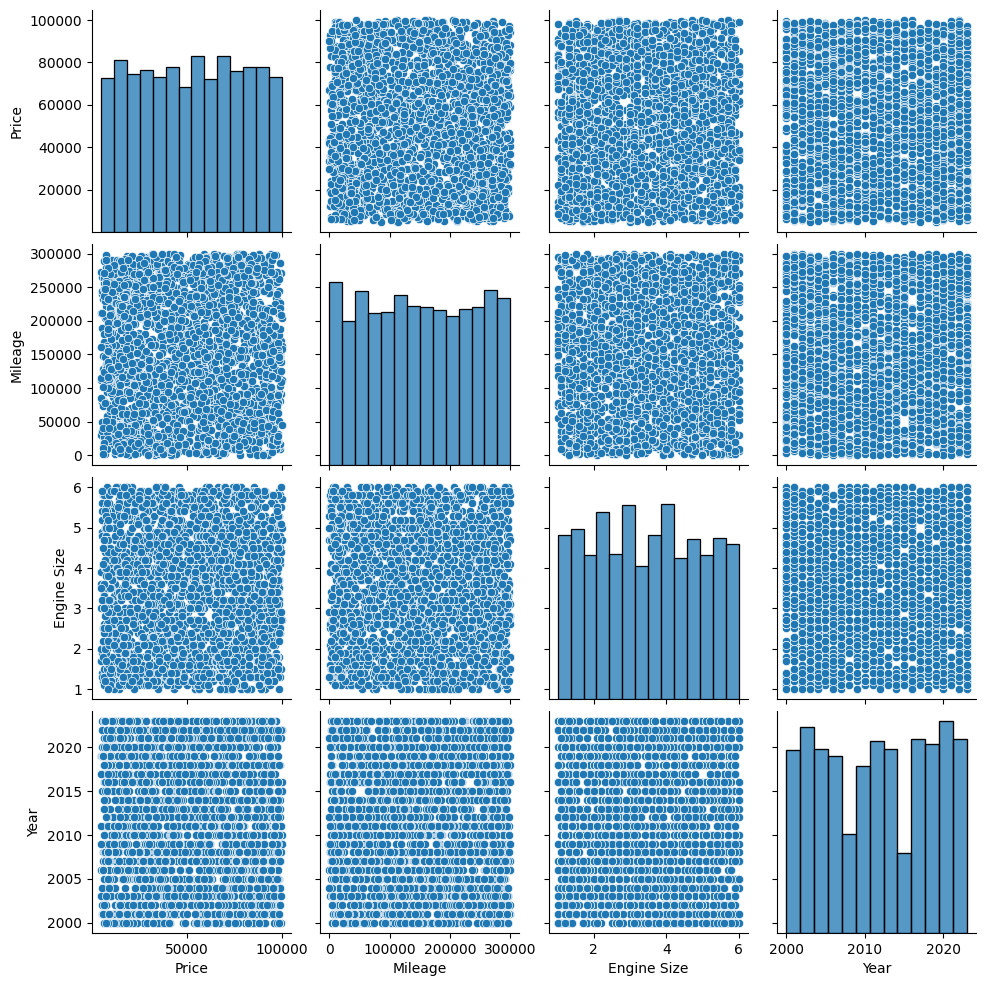

In [64]:
# What hidden relationships exist across all numeric features?

sns.pairplot(df[["Price", "Mileage", "Engine Size", "Year"]])
plt.show()

Pair Plot Analysis — Key Insights

1.Every variable pair forms a structureless cloud — All off-diagonal scatter plots show completely random, patternless distributions, providing the strongest visual confirmation yet that no two variables in this dataset share a meaningful linear relationship.

2.Price distribution is remarkably flat — The diagonal histogram for Price shows near-uniform bars from ₹10,000 to ₹100,000, meaning vehicles are priced almost equally across all price points — an unusual and likely curated distribution.

3.Mileage skews toward higher values — The Mileage histogram shows a slight left-leaning distribution with most vehicles concentrated between 150,000–250,000 miles, indicating this dataset leans toward older or well-used vehicles.

4.Engine Size distribution is discrete and fairly balanced — The Engine Size histogram shows counts spread across sizes 1–6 with mid-sizes (3–5) being slightly more common, reflecting a realistic mix of economy to performance vehicles.

5.Year distribution confirms a 2020 peak — The Year histogram aligns with the earlier line chart finding, showing 2020 as the highest bar and a recent dip post-2021, consistent with the manufacturing trend observed previously.

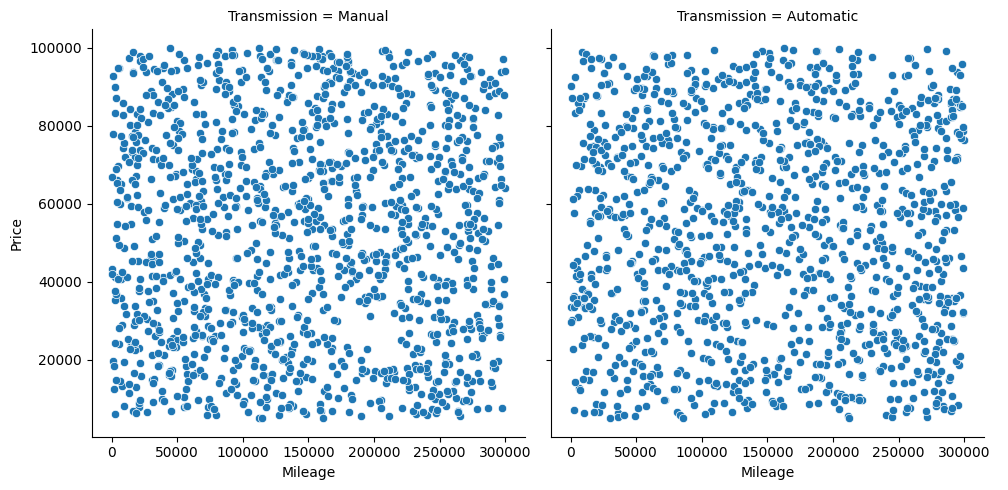

In [49]:
g = sns.FacetGrid(df, col="Transmission", height=5, palette="viridis")
g.map_dataframe(sns.scatterplot, x="Mileage", y="Price")
g.add_legend()
plt.show()

Mileage vs Price by Transmission Type — Key Insights

1.Neither transmission type shows any mileage-price correlation — Both Manual and Automatic scatter plots display a completely random cloud pattern, confirming that mileage has no meaningful influence on price regardless of transmission type.

2.Manual has a visibly higher data point density — The left panel is noticeably more populated, aligning with the earlier finding that Manual vehicles (~1,300) outnumber Automatics (~1,200) in this dataset.

3.Both transmissions cover the full mileage and price spectrum equally — From 0 to 300,000 miles and ₹5,000 to ₹100,000, neither type clusters in any specific zone, meaning transmission type doesn't define a vehicle's usage life or price tier.

4.High-mileage vehicles are priced just as high in both categories — There's no visible price drop-off at 200,000+ miles in either panel, suggesting buyers in this market don't heavily penalize high-mileage cars on price.

5.The two plots are near-mirror images of each other — The striking visual similarity between Manual and Automatic panels confirms that transmission type adds no explanatory power to the mileage-price relationship whatsoever.

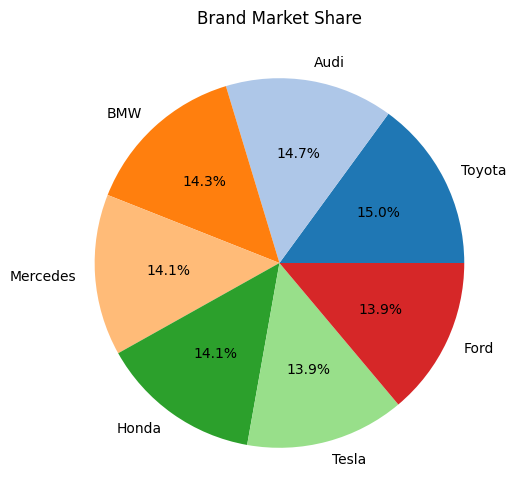

In [ ]:
# Which brands dominate your inventory?

brand_counts = df["Brand"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(brand_counts, labels=brand_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("tab20"))
plt.title("Brand Market Share")
plt.show()

Brand Market Share — Key Insights

1.Toyota holds the top spot — but barely — At 15.0%, Toyota leads the market, yet its edge over the last-place brands (Ford & Tesla at 13.9%) is a razor-thin 1.1%, making this one of the most evenly contested brand landscapes possible.

2.The market is strikingly democratic across all 7 brands — Every brand falls within a 1.1% range of each other (13.9%–15.0%), meaning no single brand dominates or controls the narrative in this dataset.

3.Ford and Tesla are tied at the bottom — Both sit at 13.9%, but being "last" here is almost meaningless given how compressed the distribution is — no brand is truly underperforming.

4.Audi and BMW cluster closely in the mid-upper tier — At 14.7% and 14.3% respectively, the European premium brands hold their ground competitively against mass-market rivals like Toyota and Honda.

5.This near-perfect uniform distribution is statistically unusual — A real-world market rarely produces such balanced share across 7 brands, suggesting this dataset may be sampled or curated to represent each brand equally rather than reflect true market proportions.

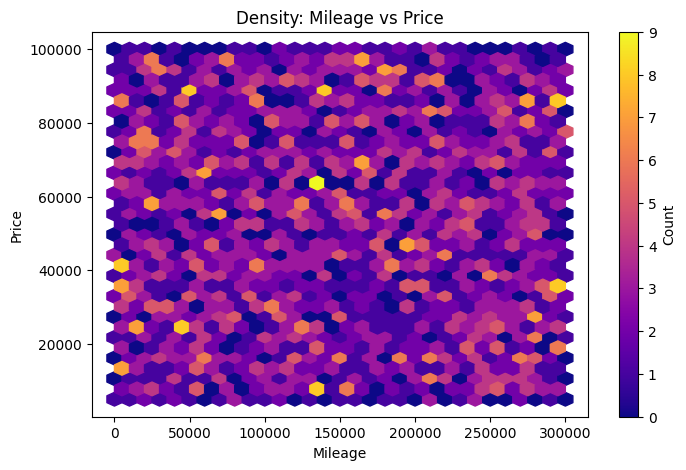

In [53]:
# Where are the highest concentrations of listings?

plt.figure(figsize=(8,5))
plt.hexbin(df["Mileage"], df["Price"], gridsize=30, cmap="plasma")
plt.colorbar(label="Count")
plt.title("Density: Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

Density: Mileage vs Price — Key Insights

1.No concentration zone exists — density is uniformly scattered — Unlike typical hexbin plots that show a clear hotspot, this one spreads color fairly evenly across the entire grid, confirming no dominant mileage-price combination in the dataset.

2.High mileage vehicles exist at every price point — Even at 250,000–300,000 miles, vehicles appear across the full ₹10,000–₹100,000 price range, suggesting mileage alone does not drive down price in this market.

3.The brightest yellow hexagons (~count 9) appear randomly — Peak density spots are scattered without a pattern, reinforcing the near-zero correlation between mileage and price seen in the correlation matrix.

4.Mid-range mileage (100,000–150,000) shows slightly warmer tones — There's a subtle concentration of orange and yellow hexagons in the 100K–150K mileage band, indicating this is the most common mileage bracket across vehicles in the dataset.

5.Low mileage does not cluster at high prices — If mileage and price were inversely related, we'd see density spike in the top-left corner — the even spread here proves that low-mileage cars aren't consis

In [ ]:
# Advanced Exploration

# Which brands perform differently across fuel types?
df.groupby(['Brand', 'Fuel Type'])['Price'].mean()

Brand     Fuel Type
Audi      Diesel       56574.073814
          Electric     51376.561170
          Hybrid       50374.120000
          Petrol       49182.028125
BMW       Diesel       59334.373587
          Electric     50654.630879
          Hybrid       55599.859302
          Petrol       50992.418764
Ford      Diesel       52679.123294
          Electric     47298.914706
          Hybrid       52169.371628
          Petrol       54045.716813
Honda     Diesel       50711.301262
          Electric     50602.706667
          Hybrid       55014.680805
          Petrol       51919.030920
Mercedes  Diesel       54449.243494
          Electric     54237.306707
          Hybrid       50099.797125
          Petrol       53719.672870
Tesla     Diesel       56368.296818
          Electric     53285.740600
          Hybrid       51733.169529
          Petrol       52309.159067
Toyota    Diesel       55101.860280
          Electric     49961.358506
          Hybrid       52509.856875
        

In [66]:
# Multi-factor pricing analysis

df.groupby(['Brand', 'Condition'])['Price'].agg(['mean', 'median', 'count'])

mean     median  count
Brand    Condition                                
Audi     Like New   51931.677658  46849.570    111
         New        50789.721473  46049.780    129
         Used       53145.078438  52992.345    128
BMW      Like New   54000.022319  56784.665    138
         New        54920.846538  58779.595    104
         Used       53659.274397  56810.935    116
Ford     Like New   52967.725403  54961.225    124
         New        53635.520088  58132.970    113
         Used       47945.888182  43716.495    110
Honda    Like New   52429.640163  56401.450    123
         New        53297.152477  51706.440    109
         Used       50528.871583  50719.930    120
Mercedes Like New   53181.418727  55132.835    110
         New        52781.500348  51393.690    115
         Used       53567.392188  54276.245    128
Tesla    Like New   55098.004793  56797.720    121
         New        49380.045714  49283.410    119
         Used       56170.430556  58360.320    108
Toyota   Like New   54968.755413  55114.420    109
         New        49256.708917  50203.075    120
         Used       52241.689310  50250.980    145

In [68]:
# Brand vs Fuel Type vs Price

df.pivot_table(values='Price', index='Brand', columns='Fuel Type', aggfunc='mean')

Fuel Type,Diesel,Electric,Hybrid,Petrol
Brand,,,,
Audi,56574.073814,51376.561170,50374.120000,49182.028125
BMW,59334.373587,50654.630879,55599.859302,50992.418764
Ford,52679.123294,47298.914706,52169.371628,54045.716813
Honda,50711.301262,50602.706667,55014.680805,51919.030920
Mercedes,54449.243494,54237.306707,50099.797125,53719.672870
Tesla,56368.296818,53285.740600,51733.169529,52309.159067
Toyota,55101.860280,49961.358506,52509.856875,49928.105476


In [70]:
# Crosstab (Transmission vs Fuel)
pd.crosstab(df['Transmission'], df['Fuel Type'])

Fuel Type,Diesel,Electric,Hybrid,Petrol
Transmission,,,,
Automatic,309,291,276,316
Manual,346,323,325,314


In [72]:
# Time-Series Trends

df.groupby('Year')['Price'].mean()

Year
2000    53094.163441
2001    48944.057706
2002    57197.476000
2003    52260.187373
2004    51517.976900
2005    57534.323592
2006    53437.595930
2007    56464.203545
2008    53104.788716
2009    52932.735778
2010    53650.244632
2011    51414.871188
2012    57092.138378
2013    52495.034737
2014    54202.577248
2015    51516.460909
2016    51977.464068
2017    49045.689175
2018    52640.946604
2019    49848.339029
2020    48281.739426
2021    48819.715089
2022    54656.139554
2023    51328.692718
Name: Price, dtype: float64

In [74]:
# QR method 

Q1 = df['Price'].quantile(0.25) 
Q3 = df['Price'].quantile(0.75) 
IQR = Q3 - Q1 
outliers = df[(df['Price'] < Q1 - 1.5*IQR) | (df['Price'] > Q3 + 1.5*IQR)] 
outliers

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Price Segment,Car Age,Value Retention,Age Group


<Axes: xlabel='Year'>

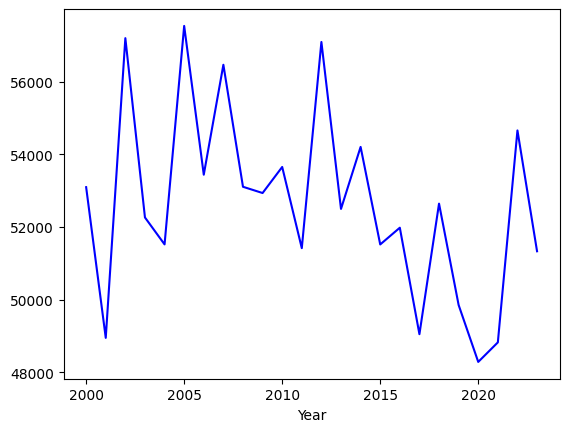

In [75]:
# Average price trend over years 

df.groupby('Year')['Price'].mean().plot(kind='line', color='blue')

<Axes: xlabel='Year'>

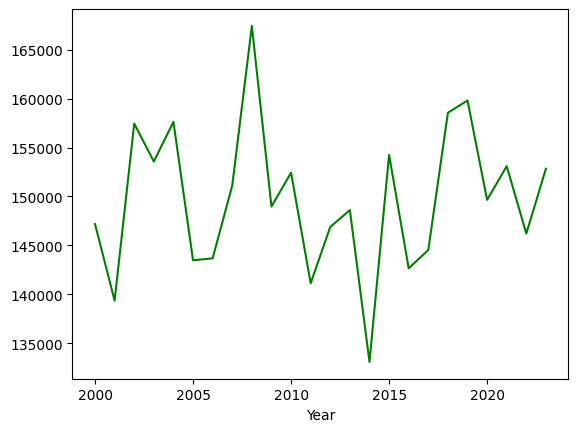

In [76]:
# Mileage trend over years 
df.groupby('Year')['Mileage'].mean().plot(kind='line', color='green')

In [ ]:
# Skewness and Kurtosis
from scipy.stats import skew, kurtosis

print("Skewness:", skew(df['Price']))
print("Kurtosis:", kurtosis(df['Price']))

Skewness: -0.014474890801717008
Kurtosis: -1.2077369163900755


In [79]:
# Key Aggregations
# Average price per brand

df.groupby('Brand')['Price'].agg(['mean', 'sum', 'count'])

,mean,sum,count
Brand,,,
Audi,51953.424810,19118860.33,368
BMW,54157.114385,19388246.95,358
Ford,51593.254813,17902859.42,347
Honda,52050.283949,18321699.95,352
Mercedes,53191.090085,18776454.80,353
Tesla,53475.547471,18609490.52,348
Toyota,52078.728235,19477444.36,374


In [80]:
# Mileage efficiency by fuel type

df.groupby('Fuel Type')['Mileage'].mean()

Fuel Type
Diesel      150379.160305
Electric    143897.392508
Hybrid      153476.469218
Petrol      151244.293651
Name: Mileage, dtype: float64

In [81]:
# Crosstab with Percentages
# Fuel preference per brand (% breakdown)

pd.crosstab(df['Brand'], df['Fuel Type'], normalize='index') * 100

Fuel Type,Diesel,Electric,Hybrid,Petrol
Brand,,,,
Audi,26.358696,25.543478,22.010870,26.086957
BMW,25.698324,25.418994,24.022346,24.860335
Ford,24.495677,24.495677,24.783862,26.224784
Honda,29.261364,21.306818,24.715909,24.715909
Mercedes,23.512748,23.229462,22.662890,30.594901
Tesla,25.287356,28.735632,24.425287,21.551724
Toyota,28.609626,23.262032,25.668449,22.459893


In [82]:
# Useful EDA Tools
# Sample data
df.sample(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Price Segment,Car Age,Value Retention,Age Group
426,427,Toyota,2013,4.3,Electric,Automatic,170623,New,21932.27,Prius,"(4916.299, 24005.534]",13,1687.097692,"(7, 15]"
1795,1796,Ford,2014,2.7,Petrol,Manual,111116,Used,45869.26,Fiesta,"(42999.798, 61994.062]",12,3822.438333,"(7, 15]"
1261,1262,Ford,2001,5.1,Electric,Manual,220073,New,60889.82,Fiesta,"(42999.798, 61994.062]",25,2435.592800,"(15, 30]"
832,833,Honda,2015,3.2,Electric,Manual,265954,Used,5535.30,Civic,"(4916.299, 24005.534]",11,503.209091,"(7, 15]"
848,849,Honda,2018,4.6,Petrol,Manual,158069,Like New,68743.32,Civic,"(61994.062, 80988.326]",8,8592.915000,"(7, 15]"


In [83]:
# Query example (powerful filtering)

df.query("Price > 50000 and Mileage < 50000")

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Price Segment,Car Age,Value Retention,Age Group
21,22,Mercedes,2022,2.3,Electric,Manual,12150,Used,61393.26,E-Class,"(42999.798, 61994.062]",4,15348.315000,"(3, 7]"
25,26,Toyota,2017,5.2,Electric,Automatic,18325,Used,70176.95,Camry,"(61994.062, 80988.326]",9,7797.438889,"(7, 15]"
28,29,Mercedes,2007,5.9,Diesel,Manual,17669,Used,78308.17,GLC,"(61994.062, 80988.326]",19,4121.482632,"(15, 30]"
36,37,Honda,2014,2.3,Diesel,Manual,25395,New,76380.32,Fit,"(61994.062, 80988.326]",12,6365.026667,"(7, 15]"
63,64,Toyota,2004,5.1,Electric,Automatic,22462,Used,69523.76,Camry,"(61994.062, 80988.326]",22,3160.170909,"(15, 30]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2469,2470,BMW,2006,5.4,Hybrid,Manual,47664,New,79574.92,X3,"(61994.062, 80988.326]",20,3978.746000,"(15, 30]"
2478,2479,BMW,2005,1.6,Diesel,Automatic,43168,New,92862.86,X3,"(80988.326, 99982.59]",21,4422.040952,"(15, 30]"
2481,2482,BMW,2022,1.7,Petrol,Automatic,28004,New,74883.99,3 Series,"(61994.062, 80988.326]",4,18720.997500,"(3, 7]"
2486,2487,Tesla,2008,5.2,Diesel,Automatic,14568,Like New,77359.25,Model 3,"(61994.062, 80988.326]",18,4297.736111,"(15, 30]"


In [84]:
# Memory usage

df.memory_usage(deep=True)

Index                 128
Car ID              20000
Brand              155002
Year                20000
Engine Size         20000
Fuel Type          158728
Transmission       161076
Mileage             20000
Condition          155035
Price               20000
Model              155100
Price Segment        2752
Car Age             20000
Value Retention     20000
Age Group            2736
dtype: int64